### Variability of classifier performance and cross-validation



In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier, Perceptron
from sklearn.datasets import make_classification
from sklearn.model_selection import (
    ShuffleSplit, LeaveOneOut, GridSearchCV,
    cross_val_predict,KFold,
    LeaveOneGroupOut, cross_val_score)
from sklearn.metrics import balanced_accuracy_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, LinearSVC
from sklearn.pipeline import Pipeline
import pandas as pd
import seaborn as sns
from tqdm import tqdm

from pathlib import Path

FIGURE_DIR = Path('../../book/book/images')
DATA_DIR = Path('../src/bettercode/data')

results_file = DATA_DIR / 'random_seed/random_seed_results.csv'
results_file.exists()


True

### The Table 1 fallacy in Machine Learning

It's very common to see tables in machine learning papers where the authors' model performance is in bold, showing that it outperforms the other models.  The simulation below shows just how unstable those results can be when different random seeds are used, even when the data stays the same.

In [6]:
# generate a dataset
n_samples = 300 # 150 for CV, 150 for testing
n_features = 1000
n_classes = 2
top_p_features = .2
n_informative = 50
seed = 42
n_datasets = 50

if not results_file.exists():
    results = []
    nruns = 1000
    rng = np.random.RandomState(seed)

    for ds in tqdm(range(n_datasets)):
        X, y = make_classification(n_samples=n_samples, n_features=n_features,
                                n_classes=n_classes, n_informative=n_informative,
                                random_state=rng)

        # refit models with different random seeds
        for run in range(nruns):
            seed = run + 1
            rng = np.random.RandomState(seed)
            np.random.seed(seed)

            pipeline = Pipeline([
                ('clf', None),
            ])
            # run CV using several different classifiers on the dataset
            # with a fixed random seed
            parameters = [
                {
                    'clf': [SGDClassifier(penalty='l2', alpha=.0001)],
                }, 
                {
                    'clf': (Perceptron(penalty='l2', alpha=.0001),),
                },

            ]
            cv = KFold(n_splits=10, shuffle=True, random_state=rng)
            grid_search = GridSearchCV(pipeline, parameters, cv=cv,
                                    scoring='accuracy', n_jobs=-3)
            grid_search.fit(X, y)
            results.append([ds] + list(grid_search.cv_results_['mean_test_score']))

    results_df = pd.DataFrame(results, columns=['Dataset', 'SGD', 'Perceptron'])
    results_df.to_csv(results_file, index=False)
else:
    results_df = pd.read_csv(results_file)

In [9]:
results_df['model_diff'] = results_df['SGD'] - results_df['Perceptron']
dataset_mean_df = results_df.groupby('Dataset').mean().reset_index()

dataset_mean_df.mean()

Dataset       24.500000
SGD            0.727678
Perceptron     0.728038
model_diff    -0.000361
dtype: float64

In [27]:
# find the maximum absolute difference between models for each dataset
max_diffs = results_df.groupby('Dataset')['model_diff'].apply(lambda x: np.max(np.abs(x))).reset_index()
max_diffs.columns = ['Dataset', 'max_model_diff']
print(max_diffs.max_model_diff.min())
print(max_diffs.max_model_diff.max())


0.07000000000000006
0.10666666666666658


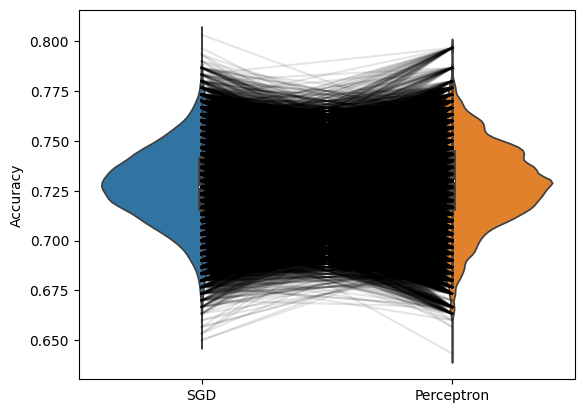

In [19]:
# violin plot of accuracys
sns.violinplot(data=results_df[['SGD', 'Perceptron']])
plt.ylabel('Accuracy')  

# add lines connecting each dataset's two model accuracies
for i, row in results_df.iterrows():
    plt.plot([0, 1], [row['SGD'], row['Perceptron']], color='black', alpha=.1)

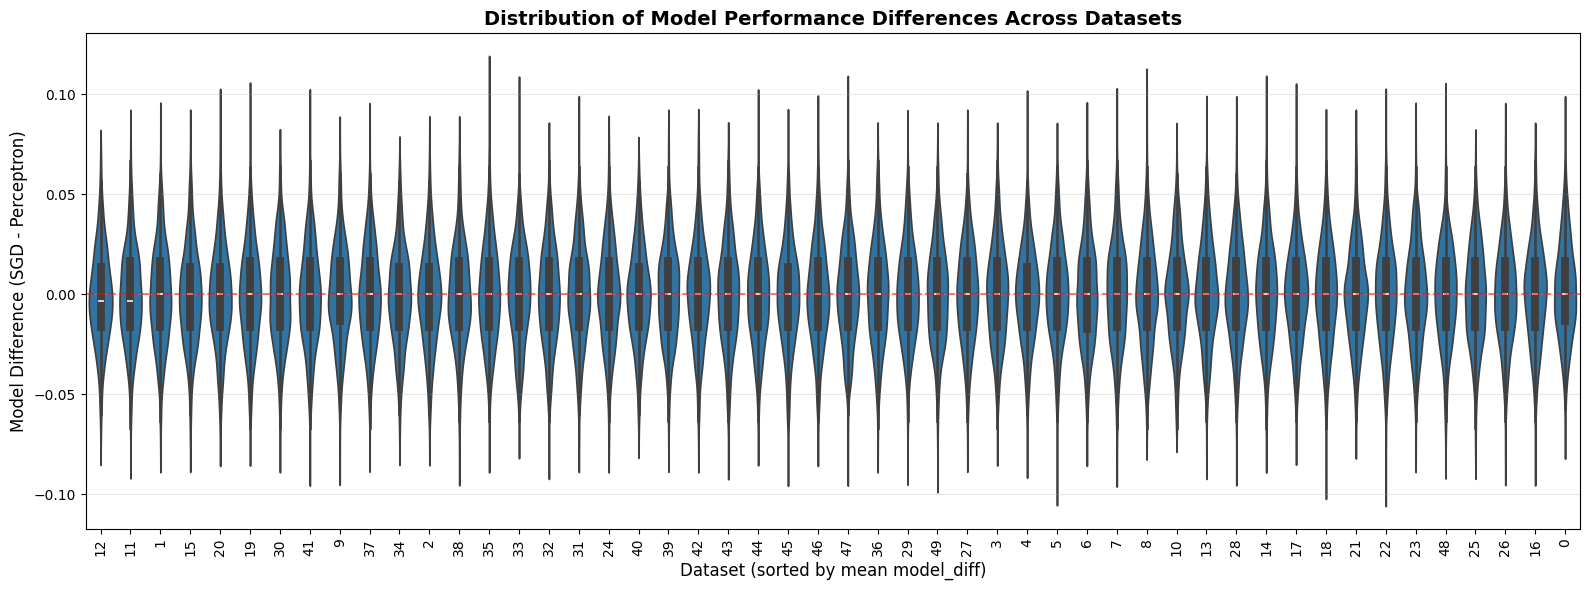

In [20]:
# Calculate mean model_diff for each dataset and sort
dataset_order = results_df.groupby('Dataset')['model_diff'].median().sort_values().index

# Create violin plot
plt.figure(figsize=(16, 6))
sns.violinplot(data=results_df, x='Dataset', y='model_diff', order=dataset_order)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.xlabel('Dataset (sorted by mean model_diff)', fontsize=12)
plt.ylabel('Model Difference (SGD - Perceptron)', fontsize=12)
plt.title('Distribution of Model Performance Differences Across Datasets', fontsize=14, fontweight='bold')
plt.xticks(rotation=90)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'seed_variability_by_dataset.png', dpi=300)
plt.show()